In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
# matplotlib.use("pgf")
# matplotlib.rcParams.update({
#     "pgf.texsystem": "pdflatex",
#     'font.family': 'serif',
#     'text.usetex': True,
#     'pgf.rcfonts': False,
# })
import seaborn as sns
import numpy as np

df = pd.read_csv('minimax.csv')

print(df.shape)
print(df.head())

(50, 3)
                                        move_history                scores  \
0  [('b', (47, 38), 0), ('r', (18, 25), 0), ('b',...  {'b': 20, 'r': -129}   
1  [('b', (47, 38), 0), ('r', (16, 25), 0), ('b',...  {'b': 27, 'r': -106}   
2  [('b', (47, 38), 0), ('r', (16, 25), 0), ('b',...    {'b': 7, 'r': -15}   
3  [('b', (47, 38), 0), ('r', (18, 25), 0), ('b',...   {'b': 14, 'r': -83}   
4  [('b', (47, 38), 0), ('r', (16, 25), 0), ('b',...      {'b': 0, 'r': 4}   

  winner  
0      b  
1      b  
2      b  
3      b  
4      r  


In [2]:
df['move_history_length'] = df['move_history'].apply(eval).apply(len)
df['red_score'] = [eval(item)['r'] for item in df['scores']]
df['blue_score'] = [eval(item)['b'] for item in df['scores']]
df['winner'] = df['winner'].apply(lambda x: "RED" if x == 'r' else "BLUE" if x == 'b' else "DRAW" if x == 't' else x)
df['score_diff'] = df['red_score'] - df['blue_score']

blue_total_wins = df['winner'].apply(lambda x: 1 if x == 'BLUE' else 0).sum()
red_total_wins = df['winner'].apply(lambda x: 1 if x == 'RED' else 0).sum()
tie_total_wins = df['winner'].apply(lambda x: 1 if x == 'DRAW' else 0).sum()

blue_average_score = df['blue_score'].mean()
red_average_score = df['red_score'].mean()

# Display the average scores
print(f"Average Blue Score: {blue_average_score}")
print(f"Average Red Score: {red_average_score}")

# Display the total wins for each player
print(f"Total Blue Wins: {blue_total_wins}, {blue_total_wins/50 * 100} %")
print(f"Total Red Wins: {red_total_wins}, {red_total_wins/50 * 100} %")
print(f"Total Tie Wins: {tie_total_wins}, {tie_total_wins/50 * 100} %")
print(f"Average Score Differential: {df['score_diff'].mean()}")

print("Column-wise Variance:\n", df['score_diff'].std())
idx = df['score_diff'].idxmax()   # gets index of the max value
max_value = df['score_diff'][idx]  # gets the value at that index

print("Index:", idx)
print("Max score_diff:", max_value)
idx = df['score_diff'].idxmin()   # gets index of the max value
min_value = df['score_diff'][idx]  # gets the value at that index

print("Index:", idx)
print("Max score_diff:", min_value)

# Display the updated DataFrame with the new column

print(df[['move_history_length', 'red_score', 'blue_score', 'winner', 'score_diff']].head())
df[['move_history_length', 'red_score', 'blue_score', 'winner', 'score_diff']].to_csv('minimax_updated.csv', index=False)


Average Blue Score: 30.68
Average Red Score: -49.52
Total Blue Wins: 42, 84.0 %
Total Red Wins: 7, 14.000000000000002 %
Total Tie Wins: 1, 2.0 %
Average Score Differential: -80.2
Column-wise Variance:
 76.26002777821874
Index: 10
Max score_diff: 38
Index: 5
Max score_diff: -322
   move_history_length  red_score  blue_score winner  score_diff
0                   44       -129          20   BLUE        -149
1                   42       -106          27   BLUE        -133
2                   47        -15           7   BLUE         -22
3                   38        -83          14   BLUE         -97
4                   38          4           0    RED           4


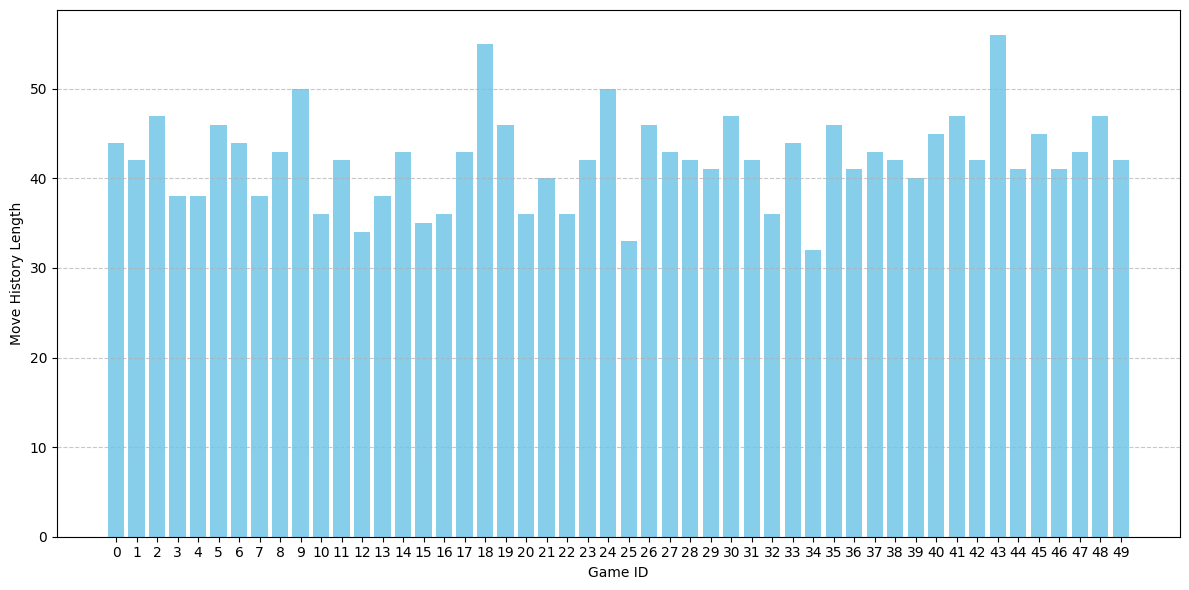

42.18


In [3]:
# Bar Plot
plt.figure(figsize=(12, 6))
plt.bar(df.index, df['move_history_length'], color='skyblue')
plt.xlabel("Game ID")
plt.ylabel("Move History Length")
# plt.title("Move History Length for 50 Games")
plt.xticks(ticks=np.arange(50), labels=np.arange(50))
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('images/minimax_bar.png', dpi=100)
plt.show()

# Average Score Plot
average_length = df['move_history_length'].mean()
print(average_length)

In [4]:
def get_difflist(history):
    red_score = 0
    blue_score = 0
    difflist = []
    for move in history:
        if move[0] == 'r':
            red_score += move[2]
        elif move[0] == 'b':
            blue_score += move[2]
        difflist.append(red_score - blue_score)
    return difflist

move_history = df['move_history'].apply(eval)
df['move_difflist'] = move_history.apply(get_difflist)
indexer = df['score_diff'].index
for idx in df.loc[indexer].index:
    replacement = int(df.at[idx, 'score_diff'])
    df.at[idx, 'move_difflist'][-1] = replacement

print(df['move_difflist'][0], type(df['move_difflist'][0]))
df['move_difflist'].to_csv('minimax_difflist.csv', index=False)

[0, 0, 0, -6, 4, 4, 4, 14, 8, -6, -6, -6, -6, -6, -96, -96, -97, -97, -102, -102, -102, -102, -102, -102, -106, -121, -121, -122, -122, -122, -122, -122, -122, -122, -122, -122, -124, -124, -129, -127, -127, -127, -127, -149] <class 'list'>


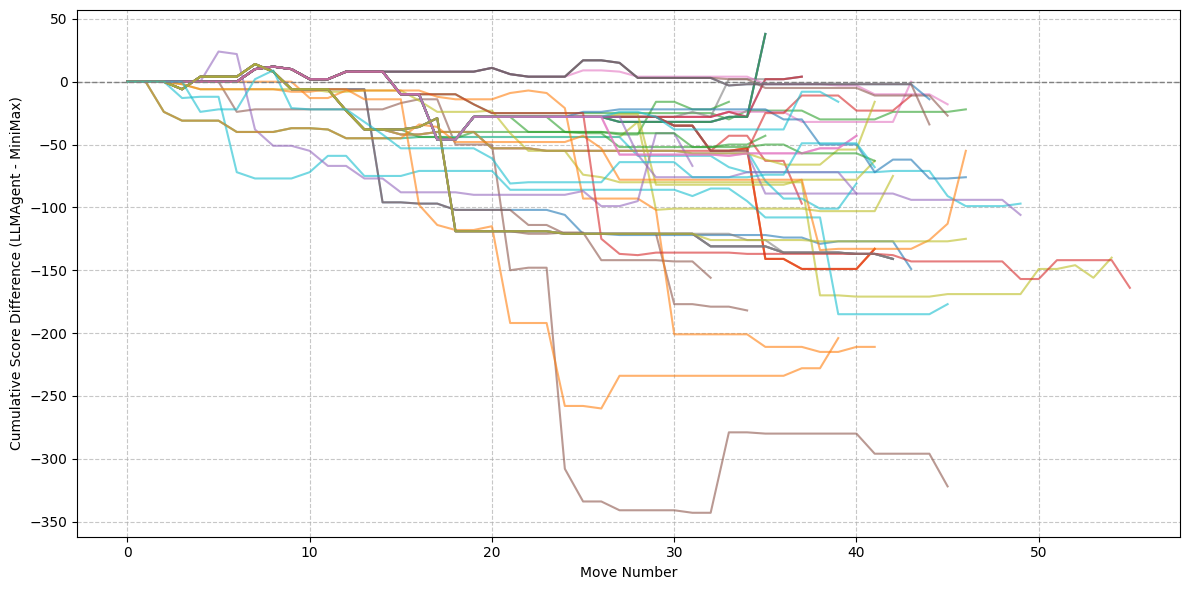

In [5]:
# Plot each game's cumulative score difference over time
plt.figure(figsize=(12, 6))

for i, row in df.iterrows():
    move_numbers = list(range(len(row["move_difflist"])))
    plt.plot(move_numbers, row["move_difflist"], label=f"Game {i+1}", alpha=0.6)

plt.xlabel("Move Number")
plt.ylabel("Cumulative Score Difference (LLMAgent - MiniMax)")
# plt.title("Cumulative Score Difference Across Moves (50 Games)")
plt.axhline(0, linestyle='--', color='gray', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.savefig('images/minimax_cumuscorediff.png', dpi=100)
plt.show()

red_score    -49.52
blue_score    30.68
dtype: float64
[-129 -106  -15  -83    4  -40    0    4  -42  -53   38 -106    3    4
 -122 -178   38 -122 -104   -4   38 -119   38 -106  -85 -137  -15 -122
  -63  -54  -36 -105  -31   28   -5  -16  -43 -122    9   -6   -3   -5
  -51  -47  -71  -23  -43 -122 -106  -40]
[ 20  27   7  14   0 282   0   0  33  44   0  27  19   0  19   4   0  19
  36 173   0  85   0  27  21  19   3  19   0  27  40 106  12  39  62  11
   0  19  25  10  11  50  12 117  18  11   0  19  19  28]


/tmp/ipykernel_6381/725505859.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([df['red_score'], df['blue_score']], vert=False, labels=['LLM Agent','MiniMax'])
/tmp/ipykernel_6381/725505859.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mean1 = avg[0]
/tmp/ipykernel_6381/725505859.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mean2 = avg[1]


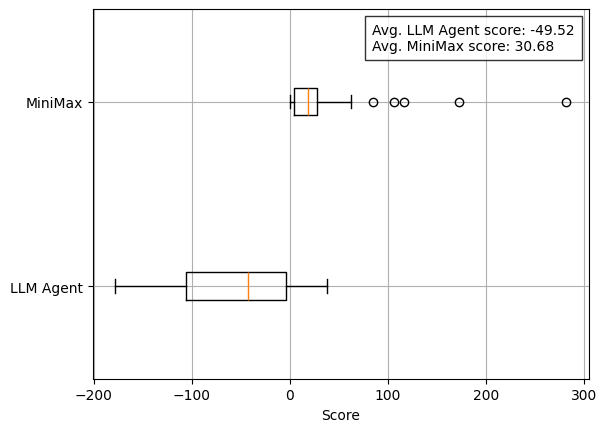

In [ ]:
avg = df[['red_score', 'blue_score']].mean()
print(avg)

red_data = df['red_score'].values
print(red_data)

blue_data = df['blue_score'].values
print(blue_data)

# plt.figure()
# plt.boxplot([red_data, blue_data], vert=False)
# plt.yticks([1, 2], ['Red', 'Blue'])
# plt.title('Boxplot: Score Spread')
# plt.xlabel('Score')
# plt.show()

from matplotlib.offsetbox import AnchoredText

# two datasets

fig, ax = plt.subplots()

# draw boxplots
ax.boxplot([df['red_score'], df['blue_score']], vert=False, labels=['LLM Agent','MiniMax'])

# compute means
mean1 = avg[0]
mean2 = avg[1]

# create an AnchoredText box in upper‑right (loc=1)
txt = AnchoredText(
    f"Avg. LLM Agent score: {mean1:.2f}\nAvg. MiniMax score: {mean2:.2f}",
    loc=1,                # 1=upper‑right
    frameon=True,         # draw the box
    pad=0.5,              # padding in font‑size units
)
# style the box (optional — you get same API as legend frame)
txt.patch.set_facecolor('white')
txt.patch.set_edgecolor('black')
txt.patch.set_alpha(0.8)

ax.add_artist(txt)
ax.set_xlabel('Score')
# ax.set_title('Boxplot: Comparing Red and Blue Scores')
plt.grid(True)
plt.savefig('images/minimax_boxplot.png', dpi=100, bbox_inches='tight')
plt.show()


In [7]:
df['winner_pretty'] = df['winner'].map({
    "RED":  "LLM Agent",
    "BLUE": "MiniMax",
    "DRAW": "DRAW"
})

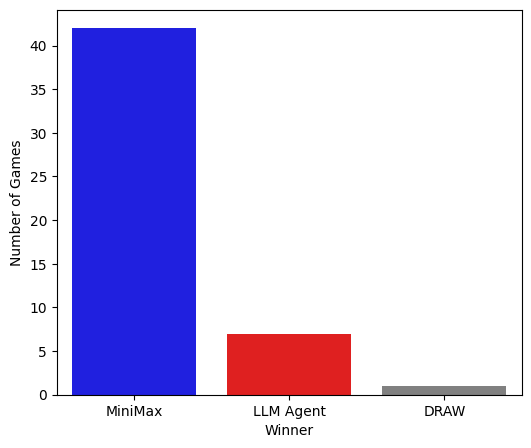

In [8]:
plt.figure(figsize=(6, 5))
sns.countplot(x='winner_pretty', hue='winner_pretty', data=df, palette={"LLM Agent": "red", "MiniMax": "blue", "DRAW": "gray"})
# plt.title('Game Outcomes')
plt.xlabel('Winner')
plt.ylabel('Number of Games')
plt.savefig('images/minimax_gameoutcomes.png', dpi=100)
plt.show()
